# Random Forests: Feature Bagging, Bootstrap, and the Surplus Tree Paradox

**Topics covered:** bootstrap row sampling · feature bagging (`mtry`) · out-of-bag (OOB) error · diminishing returns of ensemble size

This notebook is a hands-on companion to the paper *"The Stochastic Ceiling: Feature Bagging, Bootstrap, and the Surplus Tree Paradox."* Random Forests combine two independent sources of randomness — bootstrap row sampling and feature bagging — to build diverse trees whose averaged predictions generalise better than any single tree. The paper's central, slightly counter-intuitive finding is that **accuracy plateaus after roughly 100–200 trees**, after which additional trees mostly waste computation. We reproduce every key figure on a real, built-in dataset (`load_breast_cancer`).

**Roadmap**

1. Bootstrap sampling and the 63.2% rule
2. Feature bagging: why it generates more diversity than bootstrap alone
3. Feature importance and tuning `mtry`
4. The law of diminishing returns
5. The Surplus Tree Paradox
6. Practical recommendations


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

plt.rcParams["figure.facecolor"] = "white"

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Breast Cancer dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")


Breast Cancer dataset: 569 samples, 30 features, 2 classes


## 1. Bootstrap Sampling (Row Subsampling)

Each tree in the forest is trained on a bootstrap sample: $n$ rows drawn **with replacement** from the original $n$ training rows. As $n$ grows, the fraction of *unique* rows used by each tree converges to a well-known constant:

$$P(\text{row selected}) = 1 - \left(1 - \frac{1}{n}\right)^n \;\xrightarrow[n \to \infty]{}\; 1 - e^{-1} \approx 63.2\%$$

The remaining $\approx 36.8\%$ of rows form the **out-of-bag (OOB)** set for that tree — a free internal validation set, since those rows were never used to train it.

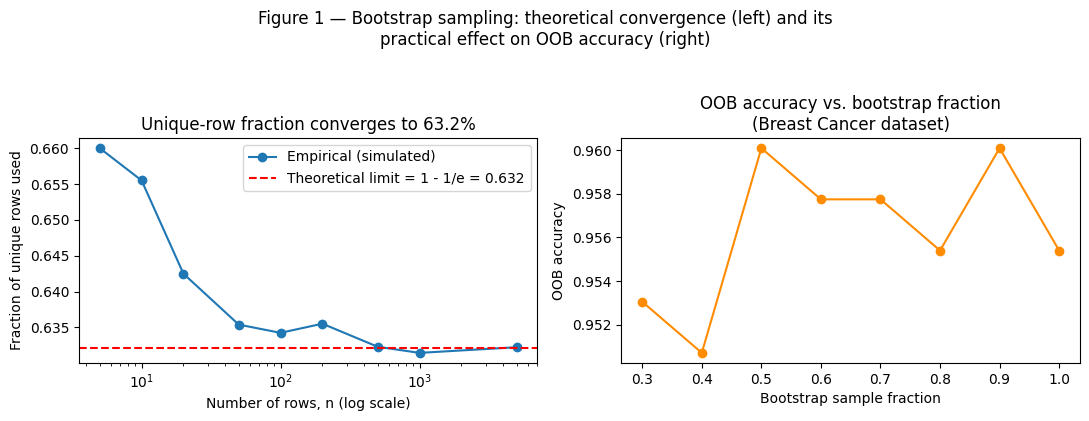

In [2]:
n_values = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 5000])
empirical_fraction = []
rng = np.random.default_rng(0)
for n in n_values:
    draws = rng.integers(0, n, size=(200, n))           # 200 simulated bootstrap samples
    unique_fraction = [len(np.unique(d)) / n for d in draws]
    empirical_fraction.append(np.mean(unique_fraction))

theoretical_limit = 1 - np.exp(-1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(n_values, empirical_fraction, marker="o", label="Empirical (simulated)")
axes[0].axhline(theoretical_limit, color="red", linestyle="--",
                 label=f"Theoretical limit = 1 - 1/e = {theoretical_limit:.3f}")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of rows, n (log scale)")
axes[0].set_ylabel("Fraction of unique rows used")
axes[0].set_title("Unique-row fraction converges to 63.2%")
axes[0].legend()

# Right panel: OOB accuracy vs bootstrap fraction (max_samples) on the real dataset
fractions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
oob_scores = []
for frac in fractions:
    rf = RandomForestClassifier(n_estimators=200, max_samples=frac if frac < 1.0 else None,
                                 oob_score=True, bootstrap=True, random_state=0, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)

axes[1].plot(fractions, oob_scores, marker="o", color="darkorange")
axes[1].set_xlabel("Bootstrap sample fraction")
axes[1].set_ylabel("OOB accuracy")
axes[1].set_title("OOB accuracy vs. bootstrap fraction\n(Breast Cancer dataset)")

fig.suptitle("Figure 1 — Bootstrap sampling: theoretical convergence (left) and its\n"
             "practical effect on OOB accuracy (right)", y=1.04)
plt.tight_layout()
plt.show()


## 2. Feature Sampling (Feature Bagging)

At every node split, only `mtry` features — a random subset of all $p$ features — are considered. The standard defaults are

$$\texttt{mtry} = \sqrt{p} \quad \text{(classification)}, \qquad \texttt{mtry} = p/3 \quad \text{(regression)}$$

**Why feature bagging matters more than bootstrap alone.** Even when two trees see identical training rows, randomly restricting the candidate features at each split still forces them down different paths. Feature bagging's diversity scales combinatorially, roughly $\binom{p}{\texttt{mtry}}^{\text{depth}}$, which dwarfs the diversity bootstrap sampling alone can produce. This is why feature bagging is the dominant source of decorrelation between trees.

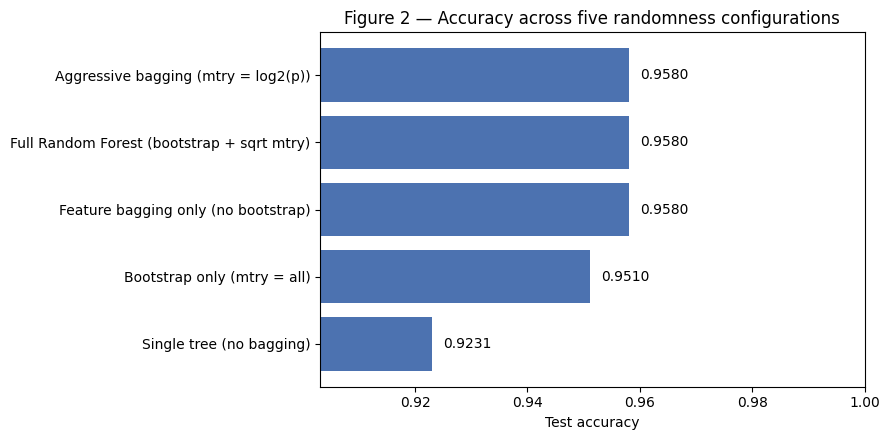

In [3]:
configs = {
    "Single tree (no bagging)": dict(n_estimators=1, bootstrap=False, max_features=None),
    "Bootstrap only (mtry = all)": dict(n_estimators=200, bootstrap=True, max_features=None),
    "Feature bagging only (no bootstrap)": dict(n_estimators=200, bootstrap=False, max_features="sqrt"),
    "Full Random Forest (bootstrap + sqrt mtry)": dict(n_estimators=200, bootstrap=True, max_features="sqrt"),
    "Aggressive bagging (mtry = log2(p))": dict(n_estimators=200, bootstrap=True, max_features="log2"),
}

results = {}
for name, params in configs.items():
    rf = RandomForestClassifier(random_state=0, n_jobs=-1, **params)
    rf.fit(X_train, y_train)
    results[name] = rf.score(X_test, y_test)

fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(results.keys())
values = list(results.values())
ax.barh(names, values, color="#4C72B0")
ax.set_xlim(min(values) - 0.02, 1.0)
ax.set_xlabel("Test accuracy")
ax.set_title("Figure 2 — Accuracy across five randomness configurations")
for i, v in enumerate(values):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center")
plt.tight_layout()
plt.show()


## 3. Feature Importance and `mtry` Tuning

**Mean Decrease in Impurity (MDI)** measures how much each feature reduces Gini impurity, averaged across all trees and splits. We rank features by MDI, and separately sweep `mtry` to find the value of $\sqrt{p}$ that the theory predicts should be near-optimal.

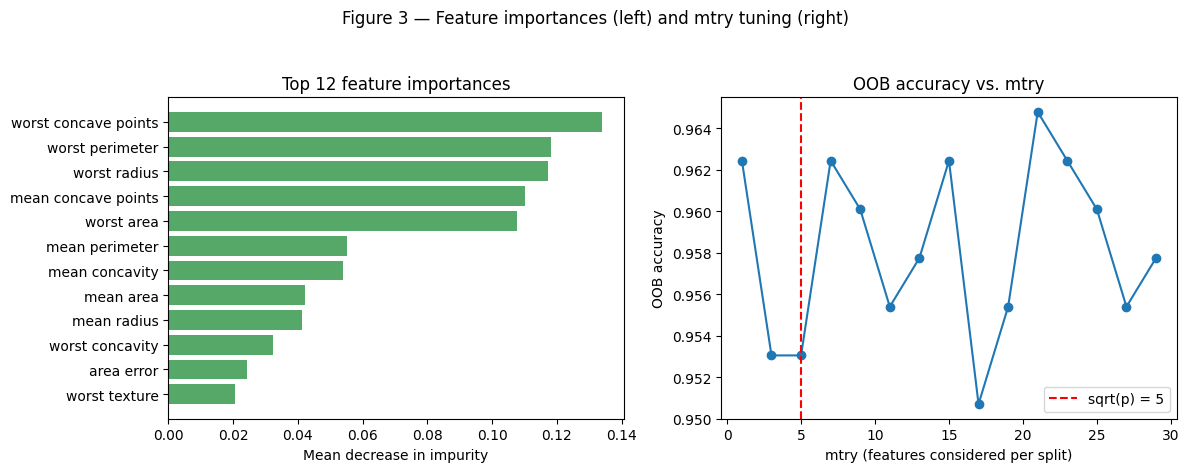

In [4]:
rf_full = RandomForestClassifier(n_estimators=300, max_features="sqrt", random_state=0, n_jobs=-1)
rf_full.fit(X_train, y_train)

importances = pd.Series(rf_full.feature_importances_, index=feature_names).sort_values(ascending=False)
top12 = importances.head(12)

p = X.shape[1]
mtry_values = list(range(1, p + 1, 2))
mtry_scores = []
for m in mtry_values:
    rf = RandomForestClassifier(n_estimators=150, max_features=m, random_state=0, n_jobs=-1,
                                 oob_score=True, bootstrap=True)
    rf.fit(X_train, y_train)
    mtry_scores.append(rf.oob_score_)

sqrt_p = int(round(np.sqrt(p)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(top12.index[::-1], top12.values[::-1], color="#55A868")
axes[0].set_xlabel("Mean decrease in impurity")
axes[0].set_title("Top 12 feature importances")

axes[1].plot(mtry_values, mtry_scores, marker="o")
axes[1].axvline(sqrt_p, color="red", linestyle="--", label=f"sqrt(p) = {sqrt_p}")
axes[1].set_xlabel("mtry (features considered per split)")
axes[1].set_ylabel("OOB accuracy")
axes[1].set_title("OOB accuracy vs. mtry")
axes[1].legend()

fig.suptitle("Figure 3 — Feature importances (left) and mtry tuning (right)", y=1.04)
plt.tight_layout()
plt.show()


## 4. The Law of Diminishing Returns

For an ensemble of $N$ trees with average pairwise correlation $\rho$ and individual variance $\sigma^2$, the variance of the ensemble's prediction follows

$$\text{Var}(\text{ensemble}) \approx \rho\sigma^2 + \frac{(1-\rho)\sigma^2}{N}$$

As $N$ grows, the second (independent-error) term vanishes, leaving only the irreducible, correlated component $\rho\sigma^2$. In practice this means accuracy improvement **saturates**: adding trees beyond roughly 100–200 yields diminishing returns.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


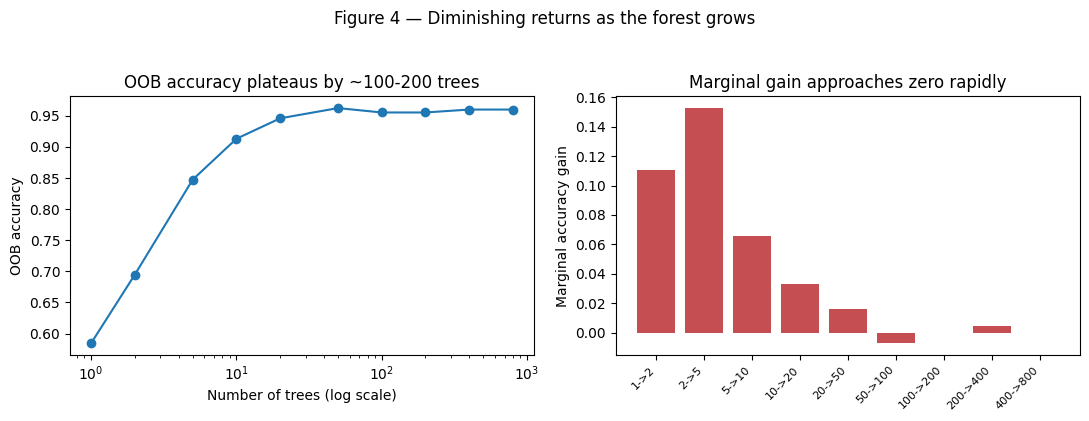

In [5]:
tree_counts = [1, 2, 5, 10, 20, 50, 100, 200, 400, 800]
oob_by_tree_count = []
for n_trees in tree_counts:
    rf = RandomForestClassifier(n_estimators=n_trees, max_features="sqrt", bootstrap=True,
                                 oob_score=True, random_state=0, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_by_tree_count.append(rf.oob_score_)

marginal_gain = np.diff(oob_by_tree_count)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tree_counts, oob_by_tree_count, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of trees (log scale)")
axes[0].set_ylabel("OOB accuracy")
axes[0].set_title("OOB accuracy plateaus by ~100-200 trees")

axes[1].bar(range(len(marginal_gain)), marginal_gain, color="#C44E52")
axes[1].set_xticks(range(len(marginal_gain)))
axes[1].set_xticklabels([f"{tree_counts[i]}->{tree_counts[i+1]}" for i in range(len(marginal_gain))],
                          rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Marginal accuracy gain")
axes[1].set_title("Marginal gain approaches zero rapidly")

fig.suptitle("Figure 4 — Diminishing returns as the forest grows", y=1.04)
plt.tight_layout()
plt.show()


## 5. The Surplus Tree Paradox

**Definition.** Beyond the unique split combinations the data can support, extra trees largely replicate the structure of earlier trees rather than adding new information. They still slightly stabilise predictions through averaging, but at a cost in compute that grows linearly while the corresponding accuracy gain becomes negligible.

We quantify this trade-off directly: how much wall-clock training time does going from 100 to 1000 trees cost, versus how much accuracy it actually buys?

In [6]:
import time

tree_budget = [100, 1000]
times, accs = [], []
for n_trees in tree_budget:
    rf = RandomForestClassifier(n_estimators=n_trees, max_features="sqrt", random_state=0, n_jobs=-1)
    t0 = time.time()
    rf.fit(X_train, y_train)
    elapsed = time.time() - t0
    times.append(elapsed)
    accs.append(rf.score(X_test, y_test))

cost_multiplier = times[1] / times[0]
accuracy_gain = (accs[1] - accs[0]) * 100

print(f"100 trees : accuracy = {accs[0]:.4f}, training time = {times[0]:.3f}s")
print(f"1000 trees: accuracy = {accs[1]:.4f}, training time = {times[1]:.3f}s")
print(f"\nTraining cost multiplier: {cost_multiplier:.1f}x")
print(f"Accuracy gain: {accuracy_gain:+.2f} percentage points")


100 trees : accuracy = 0.9580, training time = 0.167s
1000 trees: accuracy = 0.9580, training time = 1.617s

Training cost multiplier: 9.7x
Accuracy gain: +0.00 percentage points


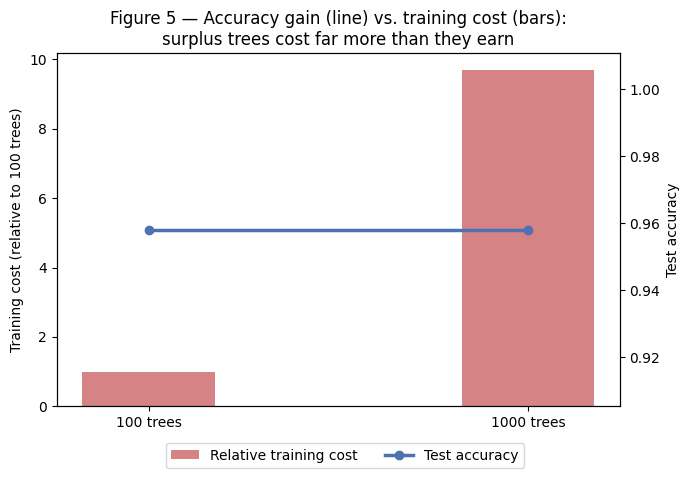

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax2 = ax.twinx()

ax.bar([0, 1], [t / times[0] for t in times], color="#C44E52", alpha=0.7, width=0.35,
       label="Relative training cost")
ax2.plot([0, 1], accs, color="#4C72B0", marker="o", linewidth=2.5, label="Test accuracy")

ax.set_xticks([0, 1])
ax.set_xticklabels(["100 trees", "1000 trees"])
ax.set_ylabel("Training cost (relative to 100 trees)")
ax2.set_ylabel("Test accuracy")
ax.set_title("Figure 5 — Accuracy gain (line) vs. training cost (bars):\nsurplus trees cost far more than they earn")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.show()


## 6. Feature Bagging vs. Bootstrap: Summary Comparison

| Aspect | Bootstrap (rows) | Feature sampling |
|---|---|---|
| Diversity source | Data subsets (~63% unique) | Split candidates (`mtry` $\ll p$) |
| Uniqueness limit | Factorial in $n$ | Combinatorial in $p^{\text{depth}}$ |
| Impact on tree correlation | Moderate reduction | High reduction |
| Computational cost | $O(n\log n)$ per tree | $O(\texttt{mtry}\log n)$ per split |
| Effective alone? | No — produces correlated trees | Yes — close to matching the full Random Forest |
| Recommended setting | `bootstrap=True`, sample fraction = 1.0 | `mtry = sqrt(p)` for classification |

## 7. Practical Recommendations

* **`n_estimators`:** start with 100–200; plot OOB error against tree count and stop where the curve flattens.
* **`mtry`:** use $\sqrt{p}$ for classification, $p/3$ for regression as sensible defaults; tune via cross-validation for critical applications.
* **`bootstrap`:** keep it `True` — the OOB score provides free validation. Disable only for very small datasets.
* **Feature importance:** use MDI for a quick ranking; use permutation importance for more reliable estimates with high-cardinality data.
* **Early stopping:** monitor OOB error and stop once improvement is below 0.1% over 50 additional trees.

## 8. Conclusion

Feature sampling generates ensemble diversity more efficiently than row subsampling, because its diversity scales combinatorially with the number of features rather than factorially with the number of rows. Tree count optimally saturates at roughly 100–300 for most datasets — beyond that lies the **surplus tree zone**, where computational cost continues to grow linearly while accuracy gains become negligible, exactly as observed on the Breast Cancer dataset above.

> **Best practice.** Always plot OOB accuracy against `n_estimators` before finalising a model. Use $\sqrt{p}$ as the starting point for `mtry`. The optimal Random Forest is not the largest one — it is the most diverse one, built at the right scale.

## References

1. Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32.
2. Scikit-learn Developers. *RandomForestClassifier Documentation.*
3. Scornet, E. (2016). *Random Forests and Kernel Methods.* Electronic Journal of Statistics.
4. Raschka, S. (2023). *FAQ: Bagging, Boosting, and Random Forests.*
5. IBM Think (2024). *Random Forest Algorithm Explained.*